# problem 1

In [22]:
import sklearn
import numpy as np
import seaborn as sns
import tensorflow as tf
import matplotlib.pyplot as plt

In [23]:
# mnist data divide
(X_train_full, y_train_full), (X_test, y_test) = tf.keras.datasets.mnist.load_data() 

In [24]:
X_train_full.shape

(60000, 28, 28)

In [3]:
X_test.shape

(10000, 28, 28)

In [25]:
X_train, X_valid = X_train_full[:50000],X_train_full[50000:]
y_train, y_valid = y_train_full[:50000],y_train_full[50000:]

In [26]:
# pixel 0-1 range
X_train = X_train / 255.0
X_valid = X_valid / 255.0
X_test = X_test / 255.0

In [11]:
y_train.shape

(50000,)

In [6]:
X_train.shape

(50000, 28, 28)

In [27]:
# model
model = tf.keras.models.Sequential([
  tf.keras.layers.Flatten(input_shape=(28, 28)),
  tf.keras.layers.Dense(128, activation='relu'),
  tf.keras.layers.Dropout(0.2),
  tf.keras.layers.Dense(10, activation='softmax')
])
model.summary()

/Users/jiyoon/Library/Python/3.9/lib/python/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_3 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

In [28]:
# model compile and train
optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)
model.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])
history = model.fit(X_train, y_train, epochs=5, validation_data=(X_valid, y_valid))

Epoch 1/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 2s 968us/step - accuracy: 0.8517 - loss: 0.5173 - val_accuracy: 0.9560 - val_loss: 0.1509
Epoch 2/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 1s 904us/step - accuracy: 0.9509 - loss: 0.1647 - val_accuracy: 0.9689 - val_loss: 0.1029
Epoch 3/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 1s 899us/step - accuracy: 0.9627 - loss: 0.1225 - val_accuracy: 0.9728 - val_loss: 0.0877
Epoch 4/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 1s 906us/step - accuracy: 0.9712 - loss: 0.0926 - val_accuracy: 0.9743 - val_loss: 0.0845
Epoch 5/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 1s 863us/step - accuracy: 0.9761 - loss: 0.0769 - val_accuracy: 0.9770 - val_loss: 0.0741


313/313 - 0s - 437us/step - accuracy: 0.9762 - loss: 0.0789


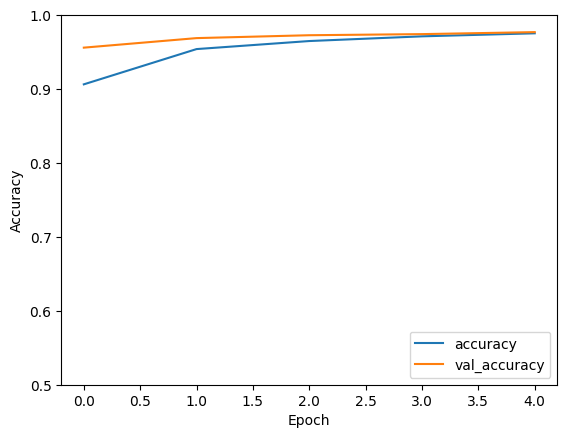

In [29]:
# model evaluate

plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label = 'val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0.5, 1])
plt.legend(loc='lower right')

test_loss, test_acc = model.evaluate(X_test,  y_test, verbose=2)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 311us/step


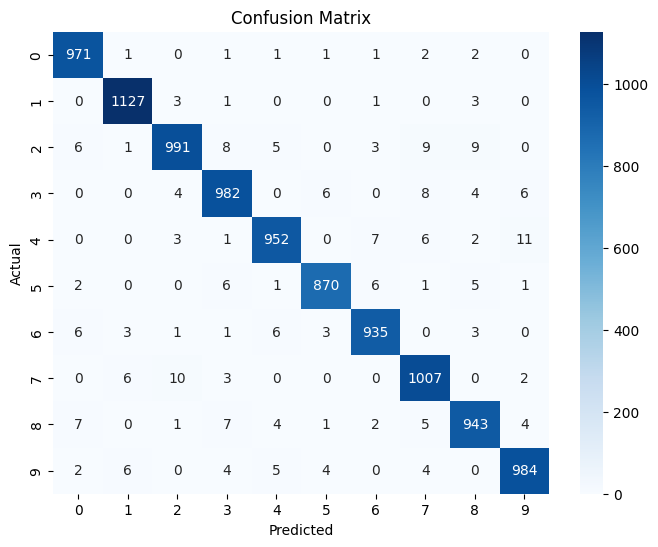

               ===classification report===
              precision    recall  f1-score   support

           0       0.98      0.99      0.98       980
           1       0.99      0.99      0.99      1135
           2       0.98      0.96      0.97      1032
           3       0.97      0.97      0.97      1010
           4       0.98      0.97      0.97       982
           5       0.98      0.98      0.98       892
           6       0.98      0.98      0.98       958
           7       0.97      0.98      0.97      1028
           8       0.97      0.97      0.97       974
           9       0.98      0.98      0.98      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000



In [ ]:
y_pred = np.argmax(model.predict(X_test), axis=1)
y_true = y_test.flatten() 

cm = sklearn.metrics.confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

print("               ===classification report===")
print(sklearn.metrics.classification_report(y_true, y_pred))

change activation function = sigmoid

In [34]:
model2 = tf.keras.models.Sequential([
  tf.keras.layers.Flatten(input_shape=(28, 28)),
  tf.keras.layers.Dense(128, activation='sigmoid'),
  tf.keras.layers.Dropout(0.2),
  tf.keras.layers.Dense(10, activation='softmax')
])

/Users/jiyoon/Library/Python/3.9/lib/python/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 2s 958us/step - accuracy: 0.7780 - loss: 0.8059 - val_accuracy: 0.9297 - val_loss: 0.2479
Epoch 2/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 1s 857us/step - accuracy: 0.9223 - loss: 0.2693 - val_accuracy: 0.9496 - val_loss: 0.1839
Epoch 3/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 1s 914us/step - accuracy: 0.9388 - loss: 0.2039 - val_accuracy: 0.9584 - val_loss: 0.1495
Epoch 4/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 1s 865us/step - accuracy: 0.9508 - loss: 0.1661 - val_accuracy: 0.9654 - val_loss: 0.1295
Epoch 5/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 1s 895us/step - accuracy: 0.9603 - loss: 0.1343 - val_accuracy: 0.9667 - val_loss: 0.1183
313/313 - 0s - 434us/step - accuracy: 0.9641 - loss: 0.1223


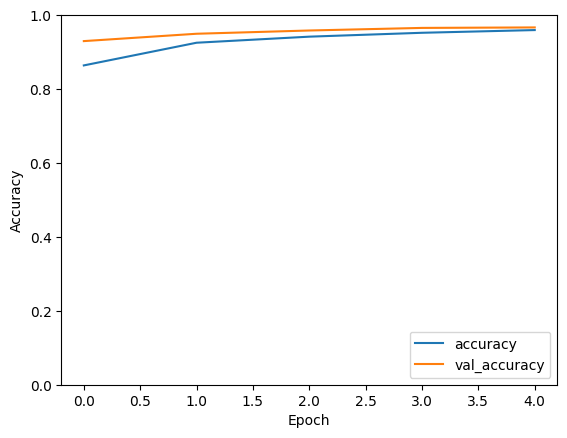

In [35]:
optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)
model2.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])
history = model2.fit(X_train, y_train, epochs=5, validation_data=(X_valid, y_valid))
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label = 'val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0, 1])
plt.legend(loc='lower right')

test_loss, test_acc = model2.evaluate(X_test,  y_test, verbose=2)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 352us/step


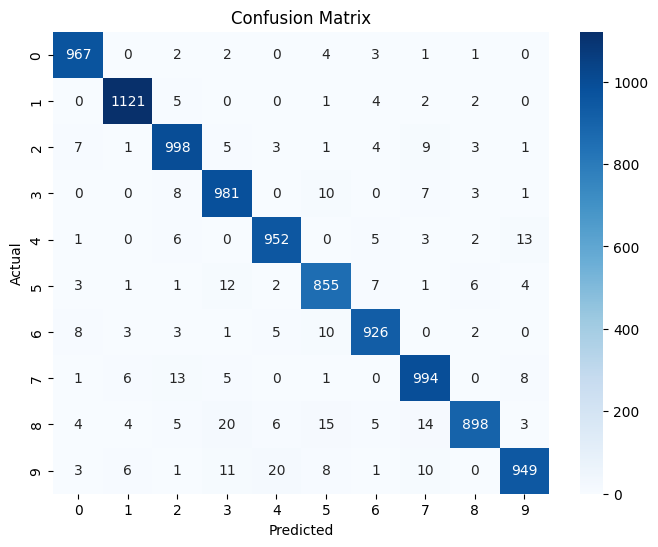

               ===classification report===
              precision    recall  f1-score   support

           0       0.97      0.99      0.98       980
           1       0.98      0.99      0.98      1135
           2       0.96      0.97      0.96      1032
           3       0.95      0.97      0.96      1010
           4       0.96      0.97      0.97       982
           5       0.94      0.96      0.95       892
           6       0.97      0.97      0.97       958
           7       0.95      0.97      0.96      1028
           8       0.98      0.92      0.95       974
           9       0.97      0.94      0.95      1009

    accuracy                           0.96     10000
   macro avg       0.96      0.96      0.96     10000
weighted avg       0.96      0.96      0.96     10000



In [43]:
y_pred = np.argmax(model2.predict(X_test), axis=1)
y_true = y_test.flatten() 

cm = sklearn.metrics.confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

print("               ===classification report===")
print(sklearn.metrics.classification_report(y_true, y_pred))

change optimizer = SGD

In [37]:
model3 = tf.keras.models.Sequential([
  tf.keras.layers.Flatten(input_shape=(28, 28)),
  tf.keras.layers.Dense(128, activation='relu'),
  tf.keras.layers.Dropout(0.2),
  tf.keras.layers.Dense(10, activation='softmax')
])

/Users/jiyoon/Library/Python/3.9/lib/python/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 1s 723us/step - accuracy: 0.6736 - loss: 1.1668 - val_accuracy: 0.9039 - val_loss: 0.3731
Epoch 2/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 1s 657us/step - accuracy: 0.8758 - loss: 0.4322 - val_accuracy: 0.9171 - val_loss: 0.3025
Epoch 3/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 1s 627us/step - accuracy: 0.8977 - loss: 0.3575 - val_accuracy: 0.9248 - val_loss: 0.2698
Epoch 4/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 1s 666us/step - accuracy: 0.9092 - loss: 0.3133 - val_accuracy: 0.9320 - val_loss: 0.2432
Epoch 5/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 1s 657us/step - accuracy: 0.9176 - loss: 0.2884 - val_accuracy: 0.9374 - val_loss: 0.2251
313/313 - 0s - 430us/step - accuracy: 0.9338 - loss: 0.2321


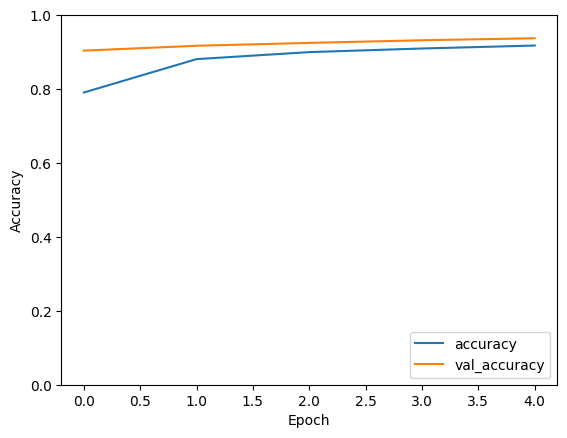

In [38]:
optimizer = tf.keras.optimizers.SGD(learning_rate=0.01)
model3.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])
history = model3.fit(X_train, y_train, epochs=5, validation_data=(X_valid, y_valid))

plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label = 'val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0, 1])
plt.legend(loc='lower right')

test_loss, test_acc = model3.evaluate(X_test,  y_test, verbose=2)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 349us/step


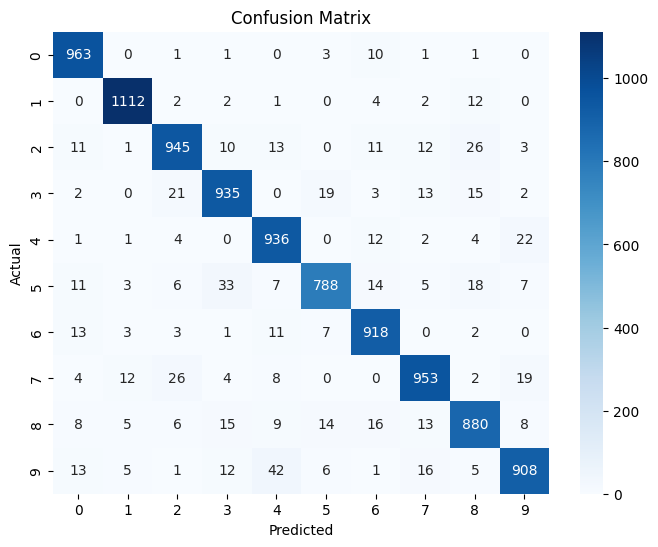

               ===classification report===
              precision    recall  f1-score   support

           0       0.94      0.98      0.96       980
           1       0.97      0.98      0.98      1135
           2       0.93      0.92      0.92      1032
           3       0.92      0.93      0.92      1010
           4       0.91      0.95      0.93       982
           5       0.94      0.88      0.91       892
           6       0.93      0.96      0.94       958
           7       0.94      0.93      0.93      1028
           8       0.91      0.90      0.91       974
           9       0.94      0.90      0.92      1009

    accuracy                           0.93     10000
   macro avg       0.93      0.93      0.93     10000
weighted avg       0.93      0.93      0.93     10000



In [44]:
y_pred = np.argmax(model3.predict(X_test), axis=1)
y_true = y_test.flatten() 

cm = sklearn.metrics.confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

print("               ===classification report===")
print(sklearn.metrics.classification_report(y_true, y_pred))

change learning rate = 0.005

In [40]:
model4 = tf.keras.models.Sequential([
  tf.keras.layers.Flatten(input_shape=(28, 28)),
  tf.keras.layers.Dense(128, activation='relu'),
  tf.keras.layers.Dropout(0.2),
  tf.keras.layers.Dense(10, activation='softmax')
])

/Users/jiyoon/Library/Python/3.9/lib/python/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 2s 987us/step - accuracy: 0.8776 - loss: 0.3936 - val_accuracy: 0.9625 - val_loss: 0.1260
Epoch 2/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 1s 919us/step - accuracy: 0.9484 - loss: 0.1683 - val_accuracy: 0.9649 - val_loss: 0.1187
Epoch 3/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 1s 935us/step - accuracy: 0.9582 - loss: 0.1399 - val_accuracy: 0.9665 - val_loss: 0.1267
Epoch 4/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 1s 883us/step - accuracy: 0.9624 - loss: 0.1276 - val_accuracy: 0.9690 - val_loss: 0.1170
Epoch 5/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 1s 903us/step - accuracy: 0.9673 - loss: 0.1096 - val_accuracy: 0.9706 - val_loss: 0.1197
313/313 - 0s - 431us/step - accuracy: 0.9705 - loss: 0.1163


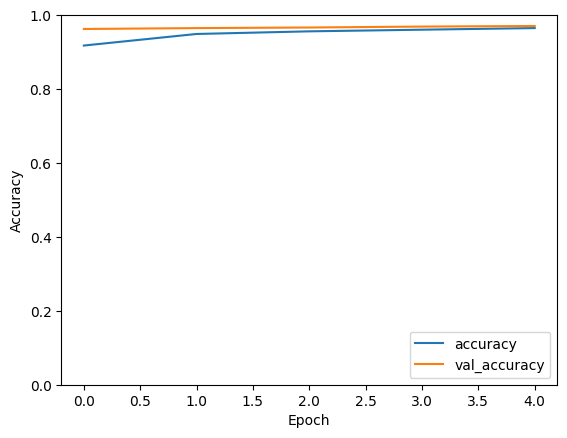

In [41]:
optimizer = tf.keras.optimizers.Adam(learning_rate=0.005)
model4.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])
history = model4.fit(X_train, y_train, epochs=5, validation_data=(X_valid, y_valid))

plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label = 'val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0, 1])
plt.legend(loc='lower right')
test_loss, test_acc = model4.evaluate(X_test,  y_test, verbose=2)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 439us/step


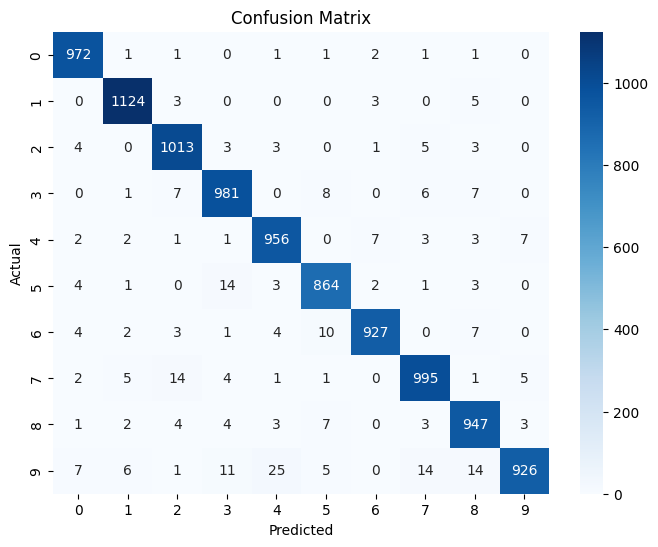

               ===classification report===
              precision    recall  f1-score   support

           0       0.98      0.99      0.98       980
           1       0.98      0.99      0.99      1135
           2       0.97      0.98      0.97      1032
           3       0.96      0.97      0.97      1010
           4       0.96      0.97      0.97       982
           5       0.96      0.97      0.97       892
           6       0.98      0.97      0.98       958
           7       0.97      0.97      0.97      1028
           8       0.96      0.97      0.96       974
           9       0.98      0.92      0.95      1009

    accuracy                           0.97     10000
   macro avg       0.97      0.97      0.97     10000
weighted avg       0.97      0.97      0.97     10000



In [45]:
y_pred = np.argmax(model4.predict(X_test), axis=1)
y_true = y_test.flatten() 

cm = sklearn.metrics.confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

print("               ===classification report===")
print(sklearn.metrics.classification_report(y_true, y_pred))

change hidden units = 64

In [46]:
model5 = tf.keras.models.Sequential([
  tf.keras.layers.Flatten(input_shape=(28, 28)),
  tf.keras.layers.Dense(64, activation='relu'),
  tf.keras.layers.Dropout(0.2),
  tf.keras.layers.Dense(10, activation='softmax')
])

/Users/jiyoon/Library/Python/3.9/lib/python/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 2s 738us/step - accuracy: 0.8180 - loss: 0.6213 - val_accuracy: 0.9508 - val_loss: 0.1834
Epoch 2/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 1s 644us/step - accuracy: 0.9359 - loss: 0.2160 - val_accuracy: 0.9641 - val_loss: 0.1356
Epoch 3/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 1s 645us/step - accuracy: 0.9506 - loss: 0.1673 - val_accuracy: 0.9655 - val_loss: 0.1246
Epoch 4/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 1s 646us/step - accuracy: 0.9577 - loss: 0.1395 - val_accuracy: 0.9689 - val_loss: 0.1051
Epoch 5/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 1s 647us/step - accuracy: 0.9619 - loss: 0.1235 - val_accuracy: 0.9698 - val_loss: 0.1025
313/313 - 0s - 410us/step - accuracy: 0.9696 - loss: 0.0996


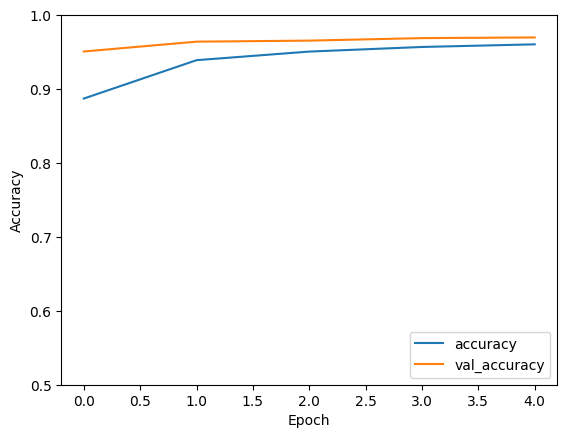

In [47]:
optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)
model5.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])
history = model5.fit(X_train, y_train, epochs=5, validation_data=(X_valid, y_valid))

plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label = 'val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0.5, 1])
plt.legend(loc='lower right')
test_loss, test_acc = model5.evaluate(X_test,  y_test, verbose=2)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 326us/step


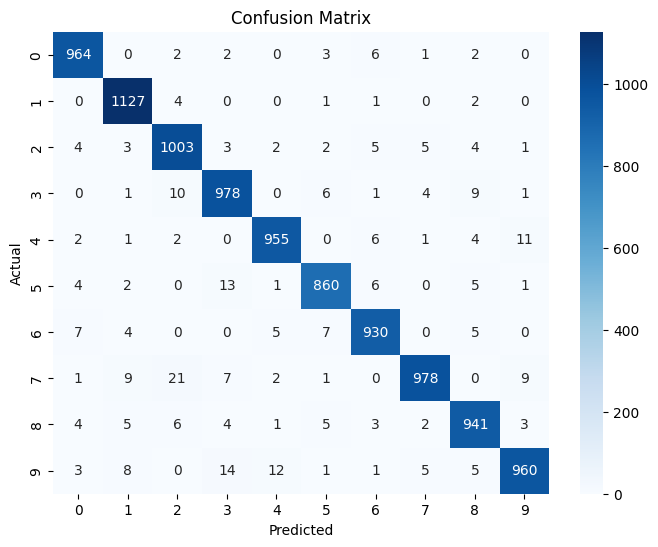

               ===classification report===
              precision    recall  f1-score   support

           0       0.97      0.98      0.98       980
           1       0.97      0.99      0.98      1135
           2       0.96      0.97      0.96      1032
           3       0.96      0.97      0.96      1010
           4       0.98      0.97      0.97       982
           5       0.97      0.96      0.97       892
           6       0.97      0.97      0.97       958
           7       0.98      0.95      0.97      1028
           8       0.96      0.97      0.96       974
           9       0.97      0.95      0.96      1009

    accuracy                           0.97     10000
   macro avg       0.97      0.97      0.97     10000
weighted avg       0.97      0.97      0.97     10000



In [48]:
y_pred = np.argmax(model5.predict(X_test), axis=1)
y_true = y_test.flatten() 

cm = sklearn.metrics.confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

print("               ===classification report===")
print(sklearn.metrics.classification_report(y_true, y_pred))

change epochs = 10

Epoch 1/10


/Users/jiyoon/Library/Python/3.9/lib/python/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1563/1563 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8488 - loss: 0.5123 - val_accuracy: 0.9594 - val_loss: 0.1478
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 2s 989us/step - accuracy: 0.9505 - loss: 0.1699 - val_accuracy: 0.9682 - val_loss: 0.1078
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 1s 917us/step - accuracy: 0.9634 - loss: 0.1207 - val_accuracy: 0.9712 - val_loss: 0.0949
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 1s 948us/step - accuracy: 0.9703 - loss: 0.0938 - val_accuracy: 0.9731 - val_loss: 0.0912
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 1s 913us/step - accuracy: 0.9755 - loss: 0.0806 - val_accuracy: 0.9756 - val_loss: 0.0844
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 1s 853us/step - accuracy: 0.9785 - loss: 0.0707 - val_accuracy: 0.9770 - val_loss: 0.0813
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 1s 867us/step - accuracy: 0.9814 - loss: 0.0570 - val_accuracy: 0.9759 - val_loss: 0.0805
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 1s 901us/step - accuracy: 0.9830 - loss: 0.0530

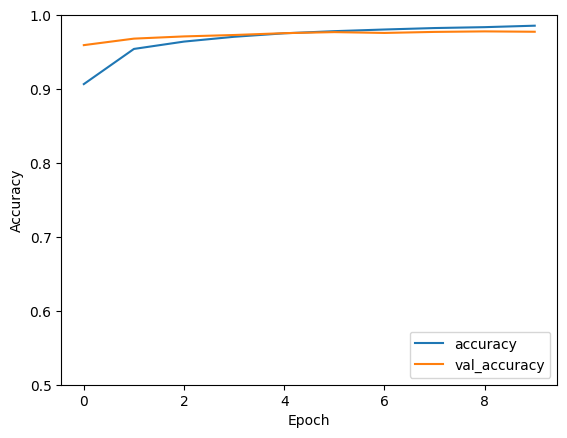

In [49]:
model6 = tf.keras.models.Sequential([
  tf.keras.layers.Flatten(input_shape=(28, 28)),
  tf.keras.layers.Dense(128, activation='relu'),
  tf.keras.layers.Dropout(0.2),
  tf.keras.layers.Dense(10, activation='softmax')
])
optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)
model6.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])
history = model6.fit(X_train, y_train, epochs=10, validation_data=(X_valid, y_valid))

plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label = 'val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0.5, 1])
plt.legend(loc='lower right')
test_loss, test_acc = model6.evaluate(X_test,  y_test, verbose=2)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 350us/step


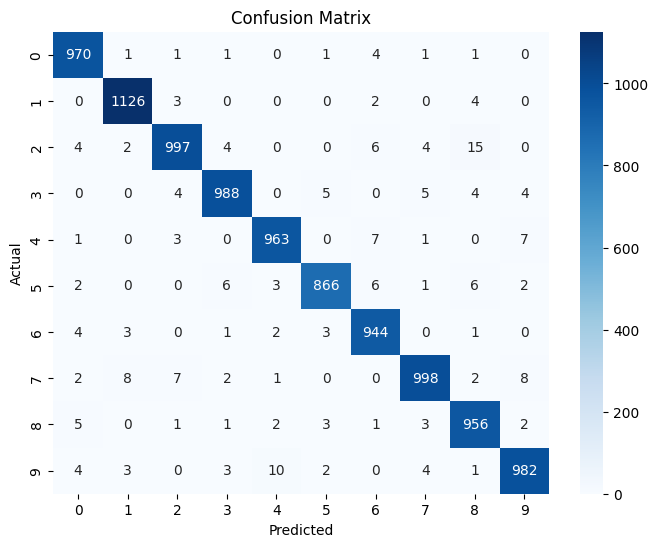

               ===classification report===
              precision    recall  f1-score   support

           0       0.98      0.99      0.98       980
           1       0.99      0.99      0.99      1135
           2       0.98      0.97      0.97      1032
           3       0.98      0.98      0.98      1010
           4       0.98      0.98      0.98       982
           5       0.98      0.97      0.98       892
           6       0.97      0.99      0.98       958
           7       0.98      0.97      0.98      1028
           8       0.97      0.98      0.97       974
           9       0.98      0.97      0.98      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000



In [50]:
y_pred = np.argmax(model6.predict(X_test), axis=1)
y_true = y_test.flatten() 

cm = sklearn.metrics.confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

print("               ===classification report===")
print(sklearn.metrics.classification_report(y_true, y_pred))